<a href="https://colab.research.google.com/github/IvanIri/Procesamiento-del-Habla/blob/main/TP2_webscrapping_preprocesamiento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP2 PROCESAMIENTO DEL HABLA

**Iván Irigoyen**


* Resolver las consignas comentando el código fuente, indicando desde dónde fue extraido o generado.

* Explicar y justificar cada paso realizado.

* Publique enlace público a su notebook en google colab y también enlace a su repositorio github de la materia.


### Entrega de los ejercicios

1. Crea un repositorio GitHub público dedicado a esta materia.
2. Sube tus notebooks de resolución para cada desafío allí.
3. Por cada desafío utilizaremos un sólo notebook.
4. Debes entregar tu TP en el foro correspondiente, siguiendo las instrucciones que allí indica.




## EJERCICIO CONSIGNA

* Cree una nube de palabras de un texto en español.

* Dicho texto puede ser descargado de Internet (webscrapping) o extraído del dataset de alguna librería.

* Puede usar cualquier libreria o herramienta para obtener el texto de su interés.

* En este notebook explica el paso a paso del proceso.



## 1- Webscrapping

Extrae un texto de Internet de una sóla página web usando alguna de las técnicas de webscrapping vistas en clase. Busca el discurso de alguna persona quien te inspire o haya dado una charla motivadora.

No puedes repetir ni usar ni el mismo texto ni la misma web que otra persona quien ya entregó en el foro.

Abajo añade los bloques de código y texto necesarios. Explica paso a paso como descargaste el texto de tu interés.


In [ ]:
! pip install requests beautifulsoup4 html5lib

In [ ]:
import requests
from bs4 import BeautifulSoup

In [ ]:
url = "https://es.wikipedia.org/wiki/Citizenship_in_a_Republic"

# creo un agente para que wikipedia me permita extraer la información
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120 Safari/537.36"
}

respuesta = requests.get(url, headers=headers)
respuesta.raise_for_status()

print("Status:", respuesta.status_code)

Status: 200


In [ ]:
sopa = BeautifulSoup(respuesta.text, 'html.parser')

In [ ]:
# Buscamos la 1ra etiqueta, ya que la frase se encuentra en una
bloque = sopa.find("blockquote")

# Extraigo el texto en formato plano (txt) y le doy indicaciones para que lo traiga bien
texto_cita = bloque.get_text(separator=" ", strip=True)

# Extraemos la frase que está entre « »
import re # importo la libreria re para buscar patrones de texto
cita = re.search(r'«(.*?)»', texto_cita, re.DOTALL)

# Muestra la frase si la encontro, sino un none y guardo la frase en una variable
if cita:
    frase = cita.group(1).strip()
else:
  frase = None
print(frase)

No es el crítico quien cuenta; ni aquél que señala cómo el hombre fuerte se tambalea, o dónde el autor de los hechos podría haberlo hecho mejor. El reconocimiento pertenece al hombre que está en la arena, con el rostro desfigurado por el polvo y el sudor y la sangre; quien se esfuerza valientemente; quien erra, quien da un traspié tras otro, pues no hay esfuerzo sin error ni fallo; pero quien realmente se empeña en lograr su cometido;
quien conoce grandes entusiasmos, las grandes devociones; quien se consagra a una causa digna; quien en el mejor de los casos encuentra al final el triunfo inherente al logro grandioso, y quien en el peor de los casos, si fracasa, al menos fracasa atreviéndose en grande, de manera que su lugar jamás estará entre aquellas almas frías y tímidas que no conocen ni la victoria ni la derrota.


## 2- Preprocesamiento

### 2.1 Muestra las stop words que tenga tu texto.

In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

frase_stop = frase.lower()

frase_stop = re.sub(r"[^\w\s]", "", frase_stop)

tokens = word_tokenize(frase_stop, language='spanish')

stop_words = set(stopwords.words('spanish'))

tokens_filtrados = [token for token in tokens if token not in stop_words]

print("Palabras eliminadas")
print(stop_words)

print("---"*100)

print("Frase sin stopwords")
print(tokens_filtrados)

Palabras eliminadas
{'hube', 'tenéis', 'quien', 'estuvimos', 'hubieron', 'tanto', 'habrá', 'habré', 'hubiera', 'ellos', 'tenemos', 'ti', 'él', 'tuyas', 'estados', 'tuvieses', 'hubo', 'sentidos', 'a', 'tenga', 'todo', 'nada', 'hubieseis', 'con', 'tengamos', 'estarán', 'teníamos', 'porque', 'cual', 'estuviesen', 'estuve', 'tengáis', 'hayas', 'estuvierais', 'vuestras', 'nuestra', 'tiene', 'seas', 'habrás', 'sentido', 'estoy', 'del', 'estando', 'e', 'estuvo', 'estén', 'tuyos', 'mí', 'seré', 'fuisteis', 'hasta', 'nuestras', 'tenía', 'estás', 'habrían', 'su', 'para', 'habremos', 'serían', 'algunos', 'ya', 'antes', 'hubieran', 'fueseis', 'tuviesen', 'tendrían', 'era', 'contra', 'mis', 'sintiendo', 'hubieras', 'hubiéramos', 'tuviésemos', 'os', 'los', 'suya', 'hayáis', 'mío', 'estaríais', 'estuviéramos', 'ante', 'tuvieseis', 'estuviste', 'una', 'hayan', 'estuvisteis', 'estaré', 'habidos', 'sin', 'estar', 'fuéramos', 'fueron', 'tenían', 'tuvisteis', 'eso', 'no', 'fue', 'tendrás', 'he', 'lo', 'fu

### 2.2 Quita las stop-words, caracteres extraños del texto. Utiliza el texto restante para crear una nube de palabras. Usa la biblioteca worldcloud de python.

In [ ]:
!pip install wordcloud

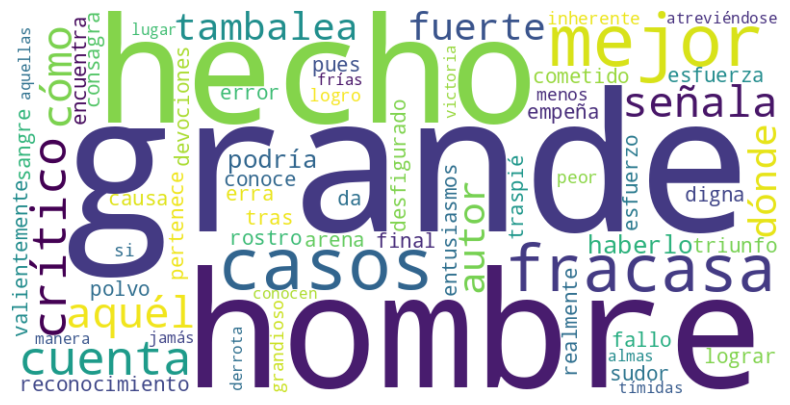

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Unimos los tokens en un solo string
texto_final = " ".join(tokens_filtrados)

# Creamos la nube de palabras
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(texto_final)

# Mostramos la nube
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

### 2.3 Usando el texto que conseguiste en el punto 1).



#### 2.3.1 Limpia y preprocesa el texto, descomponelo en oraciones, arma una matriz documento-vocabulario.


In [ ]:
import pandas as pd
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import CountVectorizer
import re

# Llamo a la variable que contenia la frase y le aplico lower() para que quede en minuscula
texto = frase.lower()

# Separo las oraciones y le agrego el ";" para separarlas correctamente
oraciones = re.split(r'[.;]', texto)

# Quito las stopwords
stop_words = set(stopwords.words('spanish'))

oraciones_limpias = []

for oracion in oraciones:
    tokens = word_tokenize(oracion, language='spanish')

    # quitar stopwords y dejar solo palabras
    tokens_filtrados = [t for t in tokens if t not in stop_words and t.isalpha()]

    # volver a unir la oración limpia
    oracion_limpia = " ".join(tokens_filtrados)

    if oracion_limpia.strip():
        oraciones_limpias.append(oracion_limpia)

# Matriz docuemnto-vocabulario
vectorizador = CountVectorizer()
matriz_documento_vocabulario = vectorizador.fit_transform(oraciones_limpias)

# Convierto en DataFrame para mejor manipulación
matriz = pd.DataFrame(
    matriz_documento_vocabulario.toarray(),
    columns=vectorizador.get_feature_names_out(),
    index=[f"Oración {i+1}" for i in range(len(oraciones_limpias))]
)

print("Oraciones limpias:")
for i, o in enumerate(oraciones_limpias, 1):
    print(f"{i}. {o}")

print("\nCantidad de oraciones:", len(oraciones_limpias))
print("Cantidad de palabras diferentes:", len(vectorizador.get_feature_names_out()))

display(matriz)

Oraciones limpias:
1. crítico cuenta
2. aquél señala cómo hombre fuerte tambalea dónde autor hechos podría haberlo hecho mejor
3. reconocimiento pertenece hombre arena rostro desfigurado polvo sudor sangre
4. esfuerza valientemente
5. erra da traspié tras pues esfuerzo error fallo
6. realmente empeña lograr cometido
7. conoce grandes entusiasmos grandes devociones
8. consagra causa digna
9. mejor casos encuentra final triunfo inherente logro grandioso peor casos si fracasa menos fracasa atreviéndose grande manera lugar jamás aquellas almas frías tímidas conocen victoria derrota

Cantidad de oraciones: 9
Cantidad de palabras diferentes: 67


,almas,aquellas,aquél,arena,atreviéndose,autor,casos,causa,cometido,conoce,...,señala,si,sudor,tambalea,tras,traspié,triunfo,tímidas,valientemente,victoria
Oración 1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Oración 2,0,0,1,0,0,1,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
Oración 3,0,0,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
Oración 4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
Oración 5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,0
Oración 6,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
Oración 7,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
Oración 8,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
Oración 9,1,1,0,0,1,0,2,0,0,0,...,0,1,0,0,0,0,1,1,0,1


In [ ]:
# top 10 palabras que más se repiten
from collections import Counter

# 1. Unimos todas las oraciones limpias en una lista de palabras
todas_palabras = " ".join(oraciones_limpias).split()

# 2. Contamos frecuencia
contador = Counter(todas_palabras)

print("\nTop 10 palabras más repetidas:")
for palabra, freq in top_10:
    print(f"{palabra}: {freq}")


Top 10 palabras más repetidas:
hombre: 2
mejor: 2
grandes: 2
casos: 2
fracasa: 2
crítico: 1
cuenta: 1
aquél: 1
señala: 1
cómo: 1



#### 2.3.2 Determina la longitud de tu vocabulario.

In [ ]:
# Longitud del texto luego de aplicarle tecnicas de limpieza

X = vectorizador.fit_transform(oraciones_limpias)

longitud_vocabulario = len(vectorizador.get_feature_names_out())
print(longitud_vocabulario)

67


In [ ]:
# Longitud del texto antes de aplicarle tecnicas de limpieza

frase = frase.lower()

palabras = re.findall(r'\b\w+\b', frase)

palabras_unicas = set(palabras)

cantidad = len(palabras_unicas)

print("Antes de quitar stopwords: ")
print("Cantidad de palabras diferentes:", cantidad)
print("              ")

# Longitud después de quitar stopword

cantidad2 = len(set(tokens_filtrados))

print("Después de quitar stopwords: ")
print("Cantidad de palabras diferentes:", cantidad2)

Antes de quitar stopwords: 
Cantidad de palabras diferentes: 95
              
Después de quitar stopwords: 
Cantidad de palabras diferentes: 67



#### 2.3.3. Aplica TF-IDF a tu matriz documento-vocabulario

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Aplicamos TF-IDF sobre las oraciones
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(oraciones_limpias)

# Lo pasamos a DataFrame para verlo mejor
matriz_tfidf = pd.DataFrame(
    X_tfidf.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

# Sumamos el TF-IDF de cada palabra (columna)
suma_tfidf = matriz_tfidf.sum(axis=0)

# Ordenamos de mayor a menor
top_5 = suma_tfidf.sort_values(ascending=False).head(5)

print("Top 5 palabras según TF-IDF:")
print(top_5)
print("                           ")
print("Matriz TF-IDF: ")
display(matriz_tfidf)

Top 5 palabras según TF-IDF:
grandes          0.755929
cuenta           0.707107
esfuerza         0.707107
valientemente    0.707107
crítico          0.707107
dtype: float64
                           
Matriz TF-IDF: 


,almas,aquellas,aquél,arena,atreviéndose,autor,casos,causa,cometido,conoce,...,señala,si,sudor,tambalea,tras,traspié,triunfo,tímidas,valientemente,victoria
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.283675,0.000000,0.000000,0.283675,0.000000,0.00000,0.0,0.000000,...,0.283675,0.000000,0.000000,0.283675,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.338771,0.000000,0.000000,0.000000,0.00000,0.0,0.000000,...,0.000000,0.000000,0.338771,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.707107,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.353553,0.353553,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.5,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.377964,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.57735,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.183453,0.183453,0.000000,0.000000,0.183453,0.000000,0.366905,0.00000,0.0,0.000000,...,0.000000,0.183453,0.000000,0.000000,0.000000,0.000000,0.183453,0.183453,0.000000,0.183453


Explica el formato de tu matriz resultante: documentos, vocabulario, tamaño. Brinda tus conclusiones.

La matriz que nos dio es una matriz de 9x67. 9 filas x 67 columnas, igual a la matriz anterior, la documento-vocabulario.

Pero el analisis mediante la matriz TF-IDF nos permite ver los terminos más representativos de la frase. Destacandose con un peso relativo más palabras como "grandes", "cuenta", "esfuerza". Esto nos dice que tiene un peso mayor en la "construcción" del mensaje.

Con la determinación de la longitud del vocabulario deducimos que hay 67 palabras diferentes, que es la cantidad de columnas en la matriz tf-idf.

# Conclusiones

Agregue aquí sus conclusiones sobre este trabajo práctico. Puede ser también parte del texto que posteará en el foro.

**Conclusión**

En el texto luego de limpiarlo (quitar stopwords y acentuaciones) nos quedo con 67 palabras diferentes, donde basandonos la sopa de letras la más recurrente es "grande" seguida de "hombres" y "casos". Pero con muy baja repetición, solo hay 5 palabrás que aparecen más de una vez, estas son "hombre", "mejor", "grandes", "casos" y "fracasa". El resto de palabras solo aparecen una vez.

Lo que nos indica que la frase tiene una buena semantica y no repite conceptos.

Esta amplitud del lenguaje utilizado también lo podemos observar en la matriz TF-IDF la cual tiene 9 filas x 67 columnas. es decir, tiene 67 palabras diferentes distribuidas en 9 oraciones, esto luego aplicarle las tecnicas de limpieza.

Sin estas tiene 95 palabras diferentes. Por lo que podemos observar que la reducción no es muy grande al aplicarle las funciones de limpiza. Esto sugiere que el proceso de limpieza elimina principalmente palabras funcionales(stopwords), sin afectar significativamente el contenido semántico del texto.


# Anexo, código de ejemplo del uso de wordcloud

Instalar e importar la librería

In [ ]:
# instalar wordcloud
!pip install wordcloud


In [ ]:

# Importar librerías
from wordcloud import WordCloud
import matplotlib.pyplot as plt


In [ ]:

# Texto de ejemplo
text = "Este es un texto de ejemplo para crear una nube de palabras usando word cloud. Puedes reemplazar este texto utilizando tu propio texto."

# Crear un objeto WordCloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)


Mostramos la imagen generada

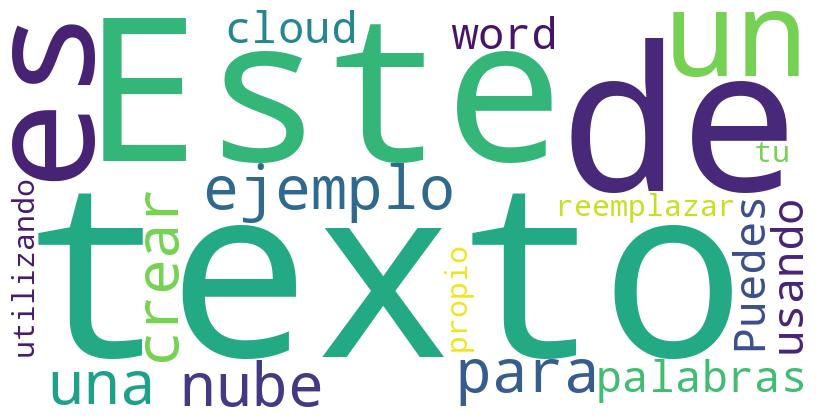

In [ ]:

# mostramos la imagen generada
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

Modificamos el ejemplo anterior agregando palabras en español que no queremos que considere para crear la nube de palabras. Estas son las stop_words



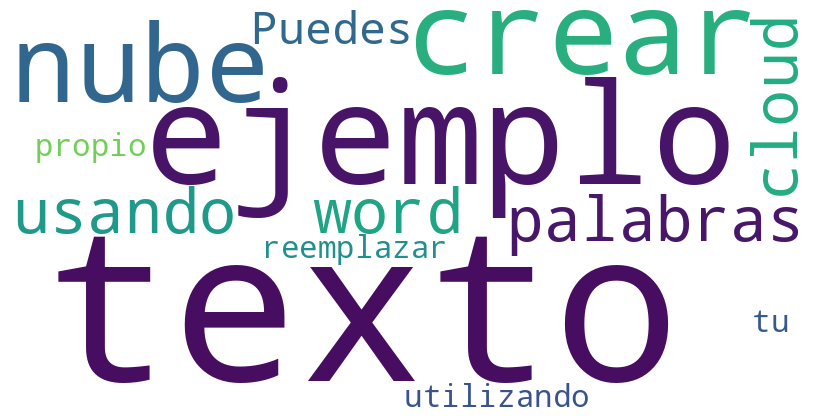

In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Texto de ejemplo
text = "Este es un texto de ejemplo para crear una nube de palabras usando word cloud. Puedes reemplazar este texto utilizando tu propio texto."

# Definir stopwords en español
stopwords_es = set(STOPWORDS)
stopwords_es.update(["con", "que", "los", "para", "un", "una", "el", "la", "en", "y", "o", "de", "a", "se", "es", "al", "como", "por", "no", "su", "más", "pero", "si", "este", "esta", "eso", "esa", "todo", "todos", "todas", "cada", "cual", "cualquier", "algo", "alguna", "algún", "ningún", "ninguna", "ninguno", "otro", "otros", "otras", "sobre", "entre", "durante", "desde", "hasta", "también", "así", "mismo", "misma", "mismo", "misma", "tan", "tanto", "tanta", "muy", "poco", "poca", "poco", "nada", "solo", "sola", "solo", "sola", "siempre", "nunca", "jamás", "casi", "aproximadamente", "cerca", "lejos", "antes", "después", "ahora", "hoy", "ayer", "mañana", "luego", "mientras", "mientras tanto", "después de", "antes de", "durante", "sin", "aunque", "a pesar de", "debido a", "gracias a", "por qué", "cómo", "dónde", "cuándo", "quién", "qué", "cuál"])

# Crear un objeto WordCloud con stopwords en español
wordcloud = WordCloud(width=800, height=400, background_color="white", stopwords=stopwords_es).generate(text)

# Mostramos la imagen generada
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()
